# Converting between GeoTIFF and NetCDF

Two models meet here. A **GeoTIFF** is a raster with *bands*; a **NetCDF** is a container of
named *variables* over shared dimensions. `pyramids` bridges them both ways:

| From | To | How |
|------|----|-----|
| GeoTIFF (1 band) | NetCDF (1 variable) | `DatasetCollection.from_files([tif]).to_netcdf(...)` |
| GeoTIFF (N bands) | NetCDF (N variables) | `to_netcdf(..., var_per_band=True)` |
| GeoTIFF (N bands) | NetCDF (1 var + band dim) | `to_netcdf(..., var_per_band=False)` |
| NetCDF (M variables) | M GeoTIFFs | `nc.get_variable(name).to_file('name.tif')` |
| NetCDF (1 var, K levels) | GeoTIFF (K bands) | `nc.get_variable(name).to_file('out.tif')` |

Writing NetCDF goes through `DatasetCollection.to_netcdf`, which uses pyramids' own GDAL
multidimensional writer (CF-1.8) and needs `xarray` (a peer dep, not a pyramids extra —
`pip install xarray`). Reading a variable back out is plain GDAL — no extra dep.

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import numpy as np

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-convert-'))  # scratch dir for outputs
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset, DatasetCollection, GeoReference
from pyramids.netcdf import NetCDF

## GeoTIFF (single band) → NetCDF

Wrap the raster in a one-file `DatasetCollection` and write it out. With `var_per_band=True`
the single band becomes a single named variable.

In [3]:
src = DATA / 'acc4000.tif'
ds = Dataset.read_file(src)
ds.shape, ds.band_count, ds.epsg

((1, 13, 14), 1, 32618)

The source is a single-band flow-accumulation raster. Plot its one band to see what we are about to convert.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


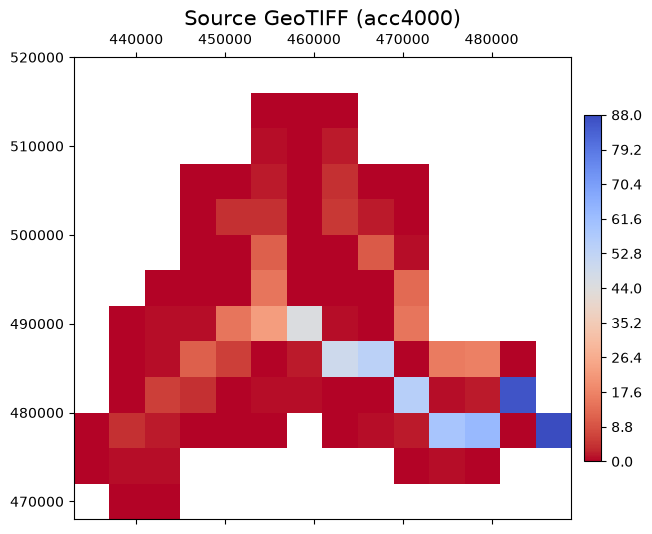

In [4]:
ds.plot(band=0, title='Source GeoTIFF (acc4000)')

In [5]:
out = WORK / 'acc.nc'
DatasetCollection.from_files([src]).to_netcdf(out, var_per_band=True)
NetCDF.read_file(out).variable_names

['Band_1']

Read the NetCDF back and plot its single variable — same data as the source raster, now stored as a named variable.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


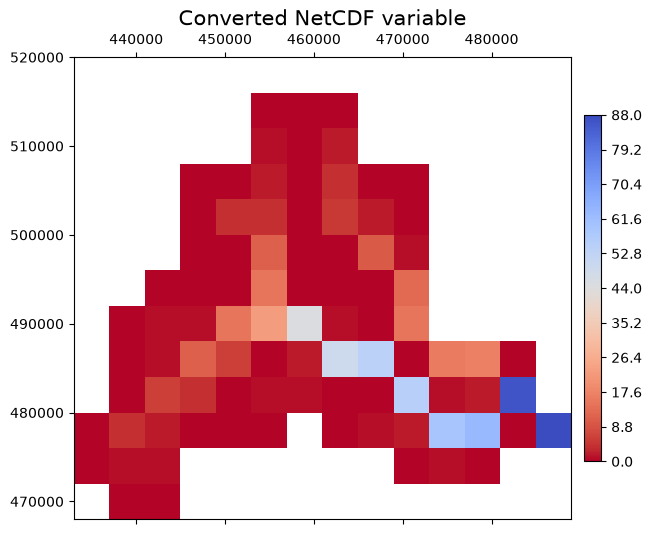

In [6]:
NetCDF.read_file(out).plot(variable='Band_1', title='Converted NetCDF variable')

## Multi-band GeoTIFF → multi-variable NetCDF

Each band maps to its own variable. Band names carry through, so set meaningful ones first
and they become the variable names (otherwise you get `Band_1`, `Band_2`, …).

In [7]:
# A synthetic 4-band image (red / green / blue / nir).
arr = np.stack([np.full((6, 8), float(i + 1)) for i in range(4)])  # (bands, rows, cols)
img = Dataset.from_array(
    arr,
    no_data_value=-9999,
    geo_ref=GeoReference(top_left_corner=(0, 0), cell_size=0.5, epsg=4326),
)
img.band_names = ['red', 'green', 'blue', 'nir']
rgbn_tif = WORK / 'rgbn.tif'
img.to_file(rgbn_tif)
img.band_count, img.band_names

(4, ['red', 'green', 'blue', 'nir'])

In [8]:
rgbn_nc = WORK / 'rgbn.nc'
DatasetCollection.from_files([rgbn_tif]).to_netcdf(rgbn_nc, var_per_band=True)
NetCDF.read_file(rgbn_nc).variable_names

['red', 'green', 'blue', 'nir']

In [9]:
# Prefer one 4-D variable with a band coordinate (handy for many bands)? var_per_band=False.
rgbn_cube = WORK / 'rgbn_cube.nc'
DatasetCollection.from_files([rgbn_tif]).to_netcdf(rgbn_cube, var_per_band=False)
NetCDF.read_file(rgbn_cube).variable_names

['data']

## Multi-variable NetCDF → GeoTIFF (one file per variable)

`get_variable(name)` pulls a single variable out as a raster-backed object; `to_file('.tif')`
writes it. Loop the variable names to export them all.

In [10]:
nc = NetCDF.read_file(DATA / 'netcdf' / 'coards__4v__1d2-2d2__scaleoffset__y-asc.nc')
nc.variable_names

['z', 'q']

In [11]:
exported = []
for name in nc.variable_names:
    tif = WORK / f'{name}.tif'
    nc.get_variable(name).to_file(tif)
    exported.append((name, Dataset.read_file(tif).shape))
exported

[('z', (1, 21, 21)), ('q', (1, 21, 21))]

Plot the first variable of the multi-variable NetCDF to see one of the rasters that was exported to GeoTIFF.

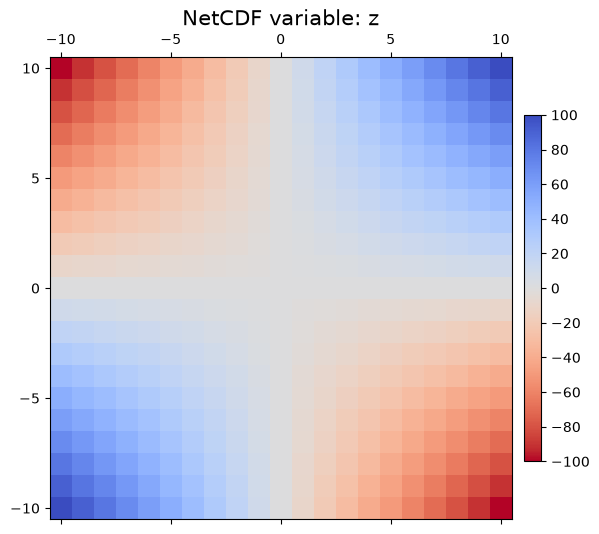

In [12]:
nc.plot(variable=nc.variable_names[0], title=f'NetCDF variable: {nc.variable_names[0]}')

## Single-variable NetCDF (with levels/time) → multi-band GeoTIFF

A variable with a non-spatial dimension (time, level, …) maps that dimension onto GeoTIFF
bands — one band per slice.

In [13]:
nc3d = NetCDF.read_file(DATA / 'netcdf' / 'cf__4v__1d3-3d1__proj__y-desc.nc')
values_tif = WORK / 'values.tif'
nc3d.get_variable('values').to_file(values_tif)
# (bands, rows, cols) — the leading NetCDF dimension became bands.
Dataset.read_file(values_tif).shape

(3, 13, 14)

## Notes

- Writing NetCDF (`to_netcdf`) needs `xarray` (`pip install xarray` — a peer dep, not a pyramids extra); reading variables back out does not.
- The writer emits CF-1.8 NetCDF with the geobox attached (`crs_wkt` / `GeoTransform`), so the
  files open cleanly in xarray, QGIS, and Panoply.
- For large cubes prefer `DatasetCollection.to_zarr` over `to_netcdf` (it streams instead of
  materialising) — see the *Other raster formats* notebook.
- See also: [Other raster formats](raster-formats.ipynb) (ASCII / COG / Zarr) and
  [Vector formats](vector-formats.ipynb).